<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

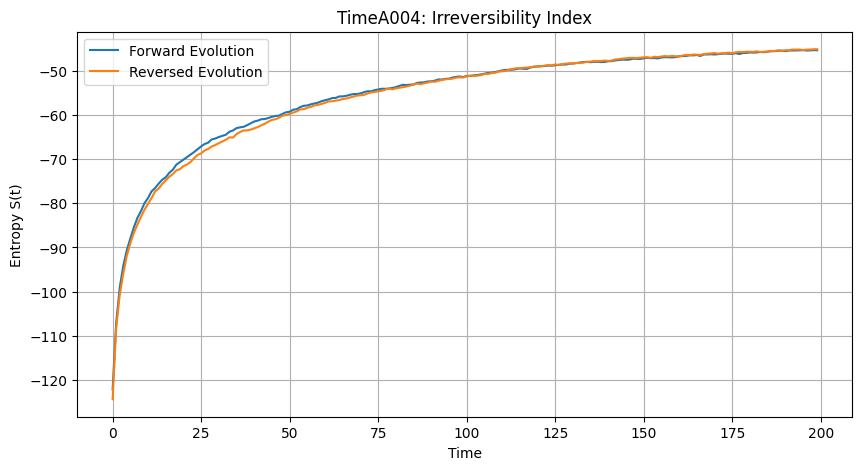

TimeA004 Metrics:
Entropy Slope (Forward): 0.17144
Memory Retention: 0.99968
Irreversibility Index: 98.06772


In [1]:
# 🔁 TimeA004: The Irreversibility Index
# Scanning lattice configurations for temporal asymmetry
# Author: Chris & Copilot | Arc V: Entropic Ascent | ACT028
# Reproducibility Tag: TimeA004_v1

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100  # lattice size
T = 200  # timesteps
curvature_strength = 0.5
xi_locking = True
seed = 42
np.random.seed(seed)

# --- Initialization ---
def initialize_lattice(N, curvature_strength):
    base = np.random.rand(N, N)
    curvature = curvature_strength * (np.sin(np.linspace(0, np.pi, N))[:, None])
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Evolution Functions ---
def evolve_forward(lattice, xi_locking):
    for _ in range(5):
        lattice += 0.01 * np.random.randn(*lattice.shape)
        if xi_locking:
            lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

def evolve_reverse(lattice, xi_locking):
    for _ in range(5):
        lattice -= 0.01 * np.random.randn(*lattice.shape)
        if xi_locking:
            lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, curvature_strength, xi_locking, reverse=False):
    lattice = initialize_lattice(N, curvature_strength)
    entropy_series = []
    for t in range(T):
        if reverse:
            lattice = evolve_reverse(lattice, xi_locking)
        else:
            lattice = evolve_forward(lattice, xi_locking)
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series)

# --- Run Forward and Reverse ---
forward_entropy = run_simulation(N, T, curvature_strength, xi_locking, reverse=False)
reverse_entropy = run_simulation(N, T, curvature_strength, xi_locking, reverse=True)

# --- Metrics ---
def compute_metrics(forward, reverse):
    slope = np.polyfit(np.arange(len(forward)), forward, 1)[0]
    memory = np.corrcoef(forward, reverse)[0,1]
    irreversibility_index = np.sum(np.abs(forward - reverse))
    return slope, memory, irreversibility_index

slope, memory, irreversibility_index = compute_metrics(forward_entropy, reverse_entropy)

# --- Plotting ---
plt.figure(figsize=(10,5))
plt.plot(forward_entropy, label='Forward Evolution')
plt.plot(reverse_entropy, label='Reversed Evolution')
plt.xlabel('Time')
plt.ylabel('Entropy S(t)')
plt.title('TimeA004: Irreversibility Index')
plt.legend()
plt.grid(True)
plt.show()

# --- Output ---
print("TimeA004 Metrics:")
print(f"Entropy Slope (Forward): {slope:.5f}")
print(f"Memory Retention: {memory:.5f}")
print(f"Irreversibility Index: {irreversibility_index:.5f}")
